# Sensitivity Analysis of ODE Market-Making Model

Global sensitivity analysis (Sobol indices) and forward uncertainty quantification
for the 3-currency (USD, EUR, GBP) ODE approximation.

See `notes/sensitivity-analysis/three_currency_setup.md` for methodology.

In [9]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde
from tqdm import tqdm
from functools import partial
import time

from src import run_multicurrency_mm
from src.model import BP
from src.sensitivity import build_modified_params, evaluate_qois, _revenue_rate
from src.sobol import saltelli_sample, evaluate_saltelli_samples, compute_sobol_indices

# Inventory magnitude (M$) used by evaluate_qois for skew/hedge/revenue QoIs
Y_MAGNITUDE = 20.0
evaluate_qois_fn = partial(evaluate_qois, y_magnitude=Y_MAGNITUDE)

## Parameter setup

20 parameters varied over uniform ranges around the paper's nominal values (Table 1).

- 5 global parameters (volatilities, correlation, risk aversion, arrival rate scale)
- 5 per pair (demand curve shape and execution cost) for EUR/USD, GBP/USD, EUR/GBP

In [10]:
PARAM_NAMES = [
    # Global (0-4)
    r"$\sigma_{\mathrm{EUR}}$", r"$\sigma_{\mathrm{GBP}}$", r"$\rho$",
    r"$\gamma$", r"$\lambda_{\mathrm{scale}}$",
    # EUR/USD (5-9)
    r"$\alpha_1^{\mathrm{EU}}$", r"$\alpha_2^{\mathrm{EU}}$",
    r"$\beta_1^{\mathrm{EU}}$", r"$\beta_2^{\mathrm{EU}}$", r"$\eta^{\mathrm{EU}}$",
    # GBP/USD (10-14)
    r"$\alpha_1^{\mathrm{GU}}$", r"$\alpha_2^{\mathrm{GU}}$",
    r"$\beta_1^{\mathrm{GU}}$", r"$\beta_2^{\mathrm{GU}}$", r"$\eta^{\mathrm{GU}}$",
    # EUR/GBP (15-19)
    r"$\alpha_1^{\mathrm{EG}}$", r"$\alpha_2^{\mathrm{EG}}$",
    r"$\beta_1^{\mathrm{EG}}$", r"$\beta_2^{\mathrm{EG}}$", r"$\eta^{\mathrm{EG}}$",
]

PARAM_LABELS = [
    "sigma_EUR", "sigma_GBP", "rho", "gamma", "lambda_scale",
    "alpha_1 EU", "alpha_2 EU", "beta_1 EU", "beta_2 EU", "eta EU",
    "alpha_1 GU", "alpha_2 GU", "beta_1 GU", "beta_2 GU", "eta GU",
    "alpha_1 EG", "alpha_2 EG", "beta_1 EG", "beta_2 EG", "eta EG",
]

# Nominal values in human-readable units
# sigma: bps, gamma: 1/M$, lambda_scale: multiplier,
# alpha: dimensionless, beta: 1/bps (paper units), eta: bps
NOMINAL = np.array([
    80.0, 70.0, 0.6, 20.0, 1.0,                         # global
    -1.9, -0.3, 11.0, 3.5, 1e-5,                         # EUR/USD
    -1.4, 0.0, 5.5, 2.0, 1.5e-5,                         # GBP/USD
    -0.5, 0.5, 3.5, 2.5, 3e-5,                           # EUR/GBP
])

RANGES = np.array([
    [56.0, 104.0],       # sigma_EUR (bps), +-30%
    [49.0, 91.0],        # sigma_GBP (bps), +-30%
    [0.3, 0.9],          # rho, +-50%
    [10.0, 40.0],        # gamma, +-50%
    [0.5, 1.5],          # lambda_scale, +-50%
    [-2.5, -1.3],        # alpha_1 EU, +-30%
    [-0.9, 0.3],         # alpha_2 EU, +-100%
    [7.7, 14.3],         # beta_1 EU (1/bps), +-30%
    [2.45, 4.55],        # beta_2 EU (1/bps), +-30%
    [0.5e-5, 2.0e-5],   # eta EU (bps), +-50%
    [-2.0, -0.8],        # alpha_1 GU
    [-0.6, 0.6],         # alpha_2 GU
    [3.85, 7.15],        # beta_1 GU (1/bps), +-30%
    [1.4, 2.6],          # beta_2 GU (1/bps), +-30%
    [0.75e-5, 3.0e-5],  # eta GU (bps), +-50%
    [-1.1, 0.1],         # alpha_1 EG
    [-0.1, 1.1],         # alpha_2 EG
    [2.45, 4.55],        # beta_1 EG (1/bps), +-30%
    [1.75, 3.25],        # beta_2 EG (1/bps), +-30%
    [1.5e-5, 6.0e-5],   # eta EG (bps), +-50%
])

QOI_NAMES = [
    # Set A: quoting policy
    r"Tier spread diff [bps]",
    r"Own-inventory skew [bps]",
    r"Cross-inventory skew [bps]",
    # Set B: hedging and economics
    r"Own-pair hedge rate [M$/day]",
    r"Cross-hedge momentum [decimal]",
    r"Net revenue [$/day]",
]

N_PARAMS = len(PARAM_NAMES)
N_QOIS = len(QOI_NAMES)

PARAM_GROUPS = ["Global"] * 5 + ["EUR/USD"] * 5 + ["GBP/USD"] * 5 + ["EUR/GBP"] * 5

GROUP_COLORS = {
    "Global":  "#2c7bb6",
    "EUR/USD": "#d7191c",
    "GBP/USD": "#fdae61",
    "EUR/GBP": "#1a9641",
}

print(f"{N_PARAMS} parameters, {N_QOIS} QoIs")
print(f"Saltelli evaluations for N=10000: {10000 * (N_PARAMS + 2):,}")

20 parameters, 6 QoIs
Saltelli evaluations for N=10000: 220,000


## Model evaluation

Map the 20-dimensional parameter vector to 6 scalar quantities of interest
via the Riccati ODE solver.

**Set A (quoting policy):**
1. Tier spread differential on EUR/USD at flat inventory
2. Own-inventory skew: EUR/USD markup shift when holding 10 M$ EUR
3. Cross-inventory skew: EUR/USD markup shift when holding 10 M$ GBP

**Set B (hedging and economics):**
4. Own-pair hedge rate: EUR/USD hedge at 10 M$ EUR
5. Cross-hedge momentum: value function gradient projected onto EUR/GBP direction at 10 M$ EUR
6. Net revenue: total revenue minus total hedging cost at 10 M$ EUR

In [11]:
# build_modified_params, evaluate_qois, and _revenue_rate are imported
# from src.sensitivity (moved there for multiprocessing compatibility).
# Quick sanity check that the import works:
print(f"evaluate_qois_fn(NOMINAL) = {evaluate_qois_fn(NOMINAL)}")

evaluate_qois_fn(NOMINAL) = [-2.10401734e-01  2.84271452e-01  1.03027201e-01 -8.13683373e+03
 -2.04066710e-05  3.03806038e+05]


## Sanity check

Verify the model evaluation at nominal parameters. Compare n_steps=500 vs 2000 to confirm
the ODE discretization error is negligible. Time a single evaluation to estimate total Sobol runtime.

In [12]:
# Evaluate at nominal with n_steps=500 (default) and n_steps=2000 (high accuracy)
qoi_500 = evaluate_qois_fn(NOMINAL)

# High-accuracy reference
mp_nom = build_modified_params(NOMINAL)
res_2000 = run_multicurrency_mm(mp_nom, n_steps=2000)

y_flat = np.zeros(3)
y_long_eur = np.array([0.0, Y_MAGNITUDE, 0.0])
y_long_gbp = np.array([0.0, 0.0, Y_MAGNITUDE])

d_t1 = res_2000.markup(0, "EUR", "USD", 1.0, y_flat)
d_t2 = res_2000.markup(1, "EUR", "USD", 1.0, y_flat)
d_t1_long_eur = res_2000.markup(0, "EUR", "USD", 1.0, y_long_eur)
d_t1_long_gbp = res_2000.markup(0, "EUR", "USD", 1.0, y_long_gbp)
xi_own_2k = res_2000.hedge_rate("EUR", "USD", y_long_eur)

# Cross-hedge momentum at n_steps=2000
ccy = mp_nom.currencies
i_eur, i_gbp = ccy.index("EUR"), ccy.index("GBP")
d_eg = np.zeros(3)
d_eg[i_eur] = 1.0
d_eg[i_gbp] = -1.0
AyB_2k = 2.0 * res_2000.A0 @ y_long_eur + res_2000.B0
p_cross_2k = -(AyB_2k @ d_eg)

R_long_2k = _revenue_rate(mp_nom, res_2000, y_long_eur)
L_total_2k = 0.0
for (a, b), pp in mp_nom.pairs.items():
    xi = res_2000.hedge_rate(a, b, y_long_eur)
    L_total_2k += (pp.psi * abs(xi) + pp.eta * xi**2) * 1e6

qoi_2000 = np.array([
    (d_t1 - d_t2) / BP,
    (d_t1_long_eur - d_t1) / BP,
    (d_t1_long_gbp - d_t1) / BP,
    xi_own_2k,
    p_cross_2k,
    R_long_2k - L_total_2k,
])

print("QoIs at nominal parameter values:")
print(f"{'QoI':>40s}  {'n=500':>12s}  {'n=2000':>12s}  {'rel err':>10s}")
for name, v500, v2000 in zip(QOI_NAMES, qoi_500, qoi_2000):
    err = abs(v500 - v2000) / (abs(v2000) + 1e-30)
    print(f"{name:>40s}  {v500:12.6g}  {v2000:12.6g}  {err:10.2e}")

# Time a single evaluation
t0 = time.time()
for _ in range(100):
    evaluate_qois_fn(NOMINAL)
t_per = (time.time() - t0) / 100
print(f"\nTime per evaluation: {t_per*1000:.1f} ms")
print(f"Estimated time for N=10000 Sobol: {t_per * 10000 * (N_PARAMS + 2) / 60:.1f} min")

QoIs at nominal parameter values:
                                     QoI         n=500        n=2000     rel err
                  Tier spread diff [bps]     -0.210402     -0.210402    2.64e-16
                Own-inventory skew [bps]      0.284271      0.284271    3.81e-14
              Cross-inventory skew [bps]      0.103027      0.103027    7.30e-13
            Own-pair hedge rate [M$/day]      -8136.83      -8136.83    6.83e-14
          Cross-hedge momentum [decimal]  -2.04067e-05  -2.04067e-05    5.31e-13
                     Net revenue [$/day]        303806        303806    7.38e-14

Time per evaluation: 9.2 ms
Estimated time for N=10000 Sobol: 33.8 min


## Sobol computation

Global sensitivity analysis using Saltelli's Monte Carlo estimator.

- First-order $S_i$: fraction of output variance due to parameter $i$ alone (Saltelli 2010)
- Total-effect $S_{T_i}$: includes all interactions involving parameter $i$ (Jansen 1999)

Total model evaluations: $N \times (k + 2) = 10{,}000 \times 22 = 220{,}000$.

Running the next two cells (~4 min with 14 workers) computes everything needed for the plots below. The **save** and **load** cells further down are opt-in — they persist or reuse results across sessions and are not part of the default top-to-bottom run.

In [5]:
N_SOBOL = 10_000
N_WORKERS = 14  # M4 Pro has 16 cores; leave 2 free

print(f"Sobol analysis: N={N_SOBOL}, k={N_PARAMS}, total evals={N_SOBOL*(N_PARAMS+2):,}")
print(f"Using {N_WORKERS} parallel workers")
print(f"Inventory magnitude: Y_MAGNITUDE = {Y_MAGNITUDE} M$")
A_samples, B_samples = saltelli_sample(N_SOBOL, RANGES, seed=42)
f_A, f_B, f_C = evaluate_saltelli_samples(evaluate_qois_fn, A_samples, B_samples, n_workers=N_WORKERS)

Sobol analysis: N=10000, k=20, total evals=220,000
Using 14 parallel workers
Inventory magnitude: Y_MAGNITUDE = 20.0 M$


Saltelli evaluations: 100%|██████████| 220000/220000 [03:46<00:00, 971.49it/s] 


In [6]:
S, S_T = compute_sobol_indices(f_A, f_B, f_C)
fwd_qois = np.concatenate([f_A, f_B], axis=0)
all_params = np.concatenate([A_samples, B_samples], axis=0)
nominal_qois = evaluate_qois_fn(NOMINAL)
N_FWD = fwd_qois.shape[0]

---

### Save results &mdash; **manual cell, do not run during a top-to-bottom execution**

The cell below writes the Saltelli evaluations, Sobol indices, and forward UQ samples to `data/sensitivity_analysis/` (a few hundred MB total). Run it only after a fresh Sobol computation when you want to persist the results to disk.

---

In [ ]:
# Save all results
save_dir = "data/sensitivity_analysis"
os.makedirs(save_dir, exist_ok=True)

np.savez(os.path.join(save_dir, "saltelli_evaluations.npz"),
         f_A=f_A, f_B=f_B, f_C=f_C, A_samples=A_samples, B_samples=B_samples)
np.savez(os.path.join(save_dir, "sobol_indices.npz"), S=S, S_T=S_T)
np.savez(os.path.join(save_dir, "forward_uq.npz"),
         fwd_qois=fwd_qois, nominal_qois=nominal_qois)

meta = {
    "N_SOBOL": int(N_SOBOL), "N_PARAMS": int(N_PARAMS), "N_QOIS": int(N_QOIS),
    "PARAM_LABELS": PARAM_LABELS, "QOI_NAMES": QOI_NAMES,
    "NOMINAL": NOMINAL.tolist(), "RANGES": RANGES.tolist(),
    "PARAM_GROUPS": PARAM_GROUPS, "seed": 42,
    "y_magnitude": float(Y_MAGNITUDE),
}
with open(os.path.join(save_dir, "metadata.json"), "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved to {save_dir}/")
for fn in sorted(os.listdir(save_dir)):
    size = os.path.getsize(os.path.join(save_dir, fn))
    print(f"  {fn}: {size / 1e6:.1f} MB")

---

### Load saved results &mdash; **manual cell, do not run during a top-to-bottom execution**

The cell below reloads previously saved results from `data/sensitivity_analysis/` and **overwrites** any `f_A`, `f_B`, `f_C`, `S`, `S_T`, `fwd_qois`, `nominal_qois`, and `all_params` currently in memory. Use it only when you want to skip the ~4 min Sobol computation above and pick up results from a prior run.

---

In [13]:
save_dir = "data/sensitivity_analysis"

d = np.load(os.path.join(save_dir, "saltelli_evaluations.npz"))
f_A, f_B, f_C = d["f_A"], d["f_B"], d["f_C"]
A_samples, B_samples = d["A_samples"], d["B_samples"]

d = np.load(os.path.join(save_dir, "sobol_indices.npz"))
S, S_T = d["S"], d["S_T"]

d = np.load(os.path.join(save_dir, "forward_uq.npz"))
fwd_qois, nominal_qois = d["fwd_qois"], d["nominal_qois"]

# Combined parameter samples matching fwd_qois row-for-row
all_params = np.concatenate([A_samples, B_samples], axis=0)

N_SOBOL = f_A.shape[0]
N_FWD = fwd_qois.shape[0]
print(f"Loaded: N_SOBOL={N_SOBOL:,}, N_FWD={N_FWD:,}, S shape={S.shape}")
print(f"Parameter samples: A={A_samples.shape}, B={B_samples.shape}, combined={all_params.shape}")

Loaded: N_SOBOL=10,000, N_FWD=20,000, S shape=(20, 6)
Parameter samples: A=(10000, 20), B=(10000, 20), combined=(20000, 20)


## Results: Sobol indices

In [14]:
# Print Sobol indices grouped by parameter category
for label, indices in [("First-order S_i", S), ("Total-effect S_Ti", S_T)]:
    print(f"\n{label}:")
    header = "  ".join(f"{'QoI '+str(q+1):>8s}" for q in range(N_QOIS))
    print(f"{'':>15s}  {header}")

    prev_group = None
    for i in range(N_PARAMS):
        group = PARAM_GROUPS[i]
        if group != prev_group:
            print(f"  --- {group} ---")
            prev_group = group
        vals = "  ".join(f"{indices[i, q]:8.3f}" for q in range(N_QOIS))
        print(f"{PARAM_LABELS[i]:>15s}  {vals}")

    sums = "  ".join(f"{indices.sum(axis=0)[q]:8.3f}" for q in range(N_QOIS))
    print(f"{'SUM':>15s}  {sums}")

print(f"\nSum of S_i:  {S.sum(axis=0)}")
print(f"Sum of S_Ti: {S_T.sum(axis=0)}")


First-order S_i:
                    QoI 1     QoI 2     QoI 3     QoI 4     QoI 5     QoI 6
  --- Global ---
      sigma_EUR     0.000     0.346     0.030     0.232     0.360     0.028
      sigma_GBP    -0.000     0.001     0.086     0.000     0.058    -0.000
            rho     0.000     0.002     0.387     0.001     0.246    -0.000
          gamma    -0.000     0.316     0.196     0.209     0.137     0.063
   lambda_scale    -0.000     0.261     0.150     0.193     0.114     0.775
  --- EUR/USD ---
     alpha_1 EU     0.039     0.006     0.014     0.007     0.006     0.004
     alpha_2 EU     0.106    -0.000    -0.000     0.000     0.000     0.042
      beta_1 EU     0.165     0.004     0.002     0.025     0.017     0.002
      beta_2 EU     0.719     0.004     0.001     0.003     0.002     0.017
         eta EU     0.000     0.000     0.000     0.145     0.000     0.007
  --- GBP/USD ---
     alpha_1 GU     0.000     0.000     0.001    -0.000    -0.000     0.012
     alpha_2 GU  

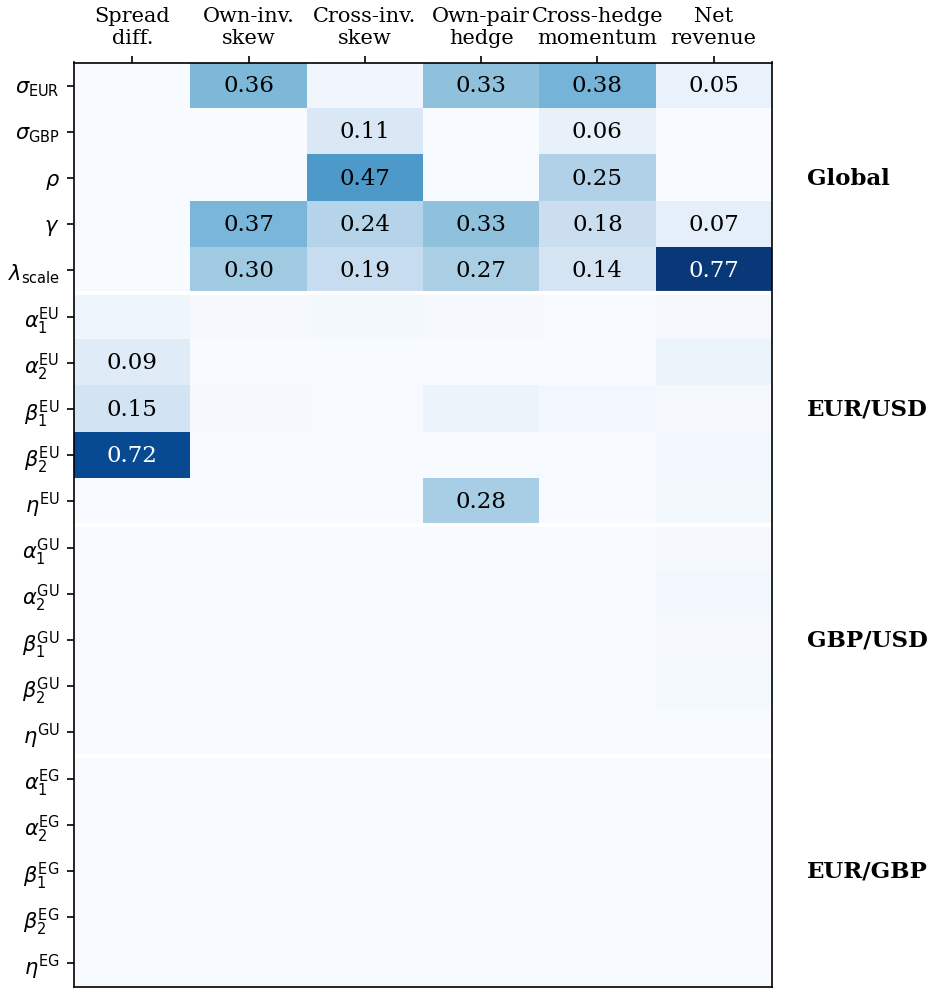

Saved: report/figures/fig_sa_heatmap.pdf


In [20]:
# --- Figure 1: Sobol heatmap (S_T) ---

from src.plotting import _RC_PARAMS
from matplotlib.transforms import blended_transform_factory

# Short QoI labels for column headers
QOI_SHORT = [
    "Spread\ndiff.", "Own-inv.\nskew", "Cross-inv.\nskew",
    "Own-pair\nhedge", "Cross-hedge\nmomentum", "Net\nrevenue",
]

# Group boundaries (rows 0-4: Global, 5-9: EUR/USD, 10-14: GBP/USD, 15-19: EUR/GBP)
group_bounds = [0, 5, 10, 15, 20]
group_names = ["Global", "EUR/USD", "GBP/USD", "EUR/GBP"]

# Heatmap needs all 4 spines, so override locally
heatmap_rc = {**_RC_PARAMS, 'axes.spines.top': True, 'axes.spines.right': True}

with plt.rc_context(heatmap_rc):
    fig, ax = plt.subplots(figsize=(6, 8))

    # White-to-blue colormap, matching the chapter's blue palette
    im = ax.imshow(S_T, aspect='auto', cmap='Blues', vmin=0, vmax=0.8,
                   interpolation='nearest')

    # Annotate cells with S_Ti > 0.05
    for i in range(N_PARAMS):
        for j in range(N_QOIS):
            val = S_T[i, j]
            if val > 0.05:
                text_color = 'white' if val > 0.55 else 'black'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        color=text_color)

    # Axes
    ax.set_xticks(range(N_QOIS))
    ax.set_xticklabels(QOI_SHORT, ha='center')
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    ax.set_yticks(range(N_PARAMS))
    ax.set_yticklabels(PARAM_NAMES)

    # Horizontal separator lines between parameter groups
    for b in group_bounds[1:-1]:
        ax.axhline(b - 0.5, color='white', linewidth=2)

    # Group labels on the right side
    trans = blended_transform_factory(ax.transAxes, ax.transData)
    for k, name in enumerate(group_names):
        mid = (group_bounds[k] + group_bounds[k+1] - 1) / 2.0
        ax.text(1.05, mid, name, ha='left', va='center',
                fontweight='bold', color='black', transform=trans)

    ax.set_xlim(-0.5, N_QOIS - 0.5)
    ax.set_ylim(N_PARAMS - 0.5, -0.5)

    fig.savefig('report/figures/fig_sa_heatmap.pdf')
    plt.show()
    print("Saved: report/figures/fig_sa_heatmap.pdf")

## Forward Uncertainty Quantification

Propagate parameter uncertainty through the ODE model and estimate the distribution
of each quantity of interest via kernel density estimation. Reuses the A and B
evaluation samples from the Sobol computation (20,000 points).

In [16]:
N_FWD = fwd_qois.shape[0]
print(f"Forward UQ using {N_FWD:,} samples")

print(f"\n{'QoI':>40s}  {'mean':>10s}  {'std':>10s}  {'5%':>10s}  {'95%':>10s}  {'nominal':>10s}")
for q in range(N_QOIS):
    data = fwd_qois[:, q]
    print(f"{QOI_NAMES[q]:>40s}  {data.mean():10.2f}  {data.std():10.2f}  "
          f"{np.percentile(data, 5):10.2f}  {np.percentile(data, 95):10.2f}  "
          f"{nominal_qois[q]:10.2f}")

Forward UQ using 20,000 samples

                                     QoI        mean         std          5%         95%     nominal
                  Tier spread diff [bps]       -0.22        0.09       -0.37       -0.09       -0.21
                Own-inventory skew [bps]        0.15        0.06        0.07        0.25        0.12
              Cross-inventory skew [bps]        0.06        0.03        0.02        0.10        0.05
            Own-pair hedge rate [M$/day]    -2895.77     3211.14    -9287.13        0.00    -1568.37
          Cross-hedge momentum [decimal]       -0.00        0.00       -0.00       -0.00       -0.00
                     Net revenue [$/day]   502253.57   239690.95   124457.23   892569.25   507731.95


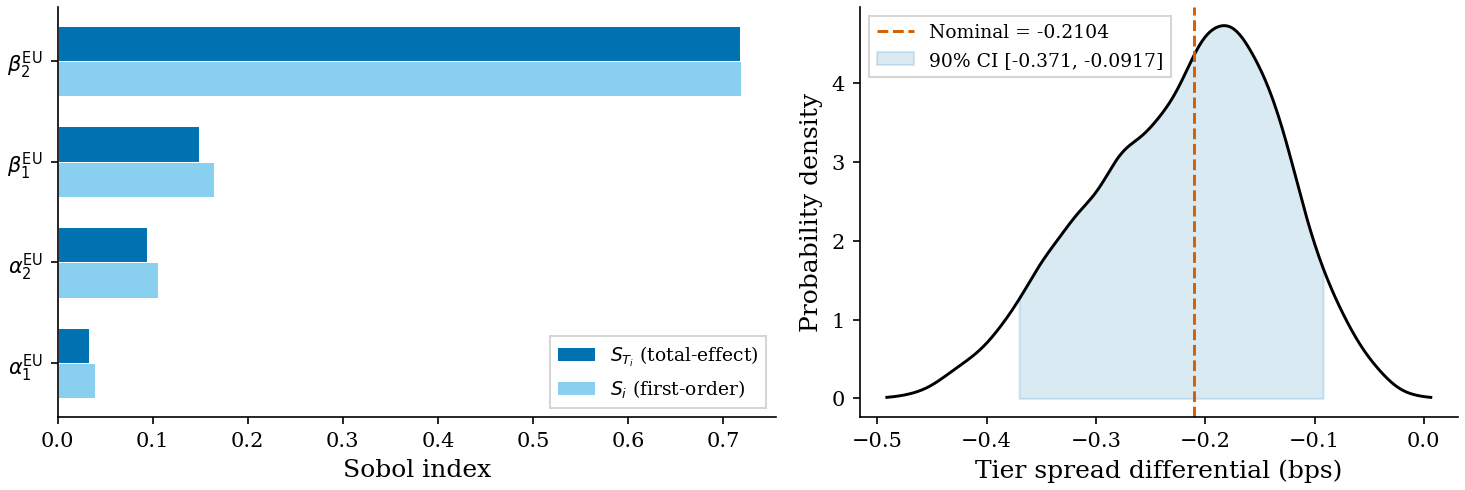

Saved: report/figures/fig_sa_qoi1.pdf


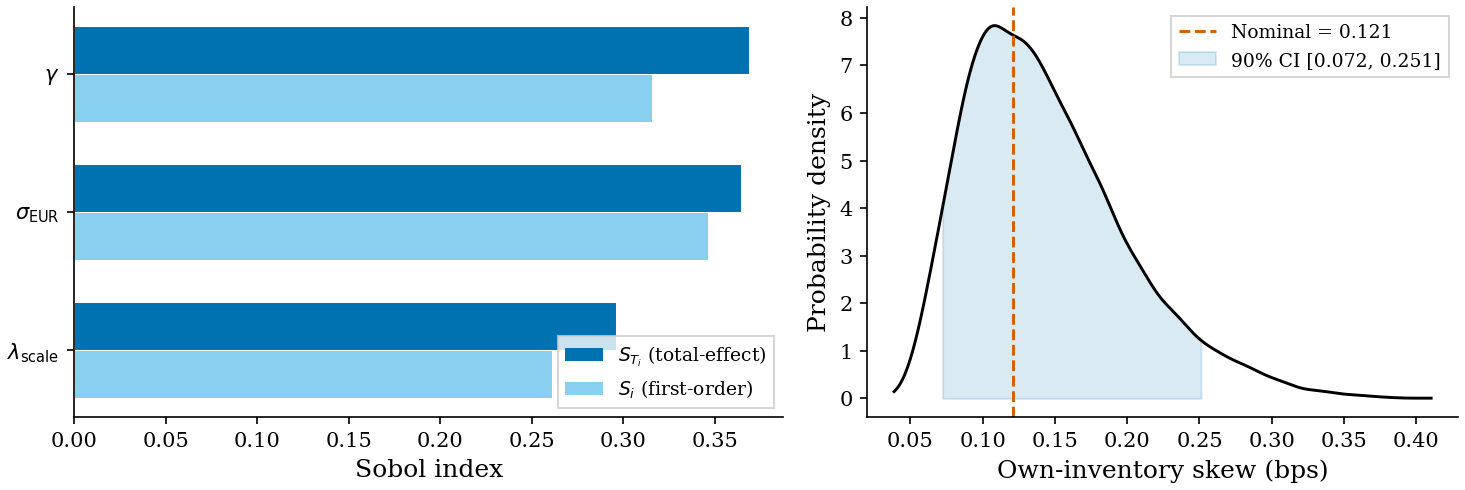

Saved: report/figures/fig_sa_qoi2.pdf


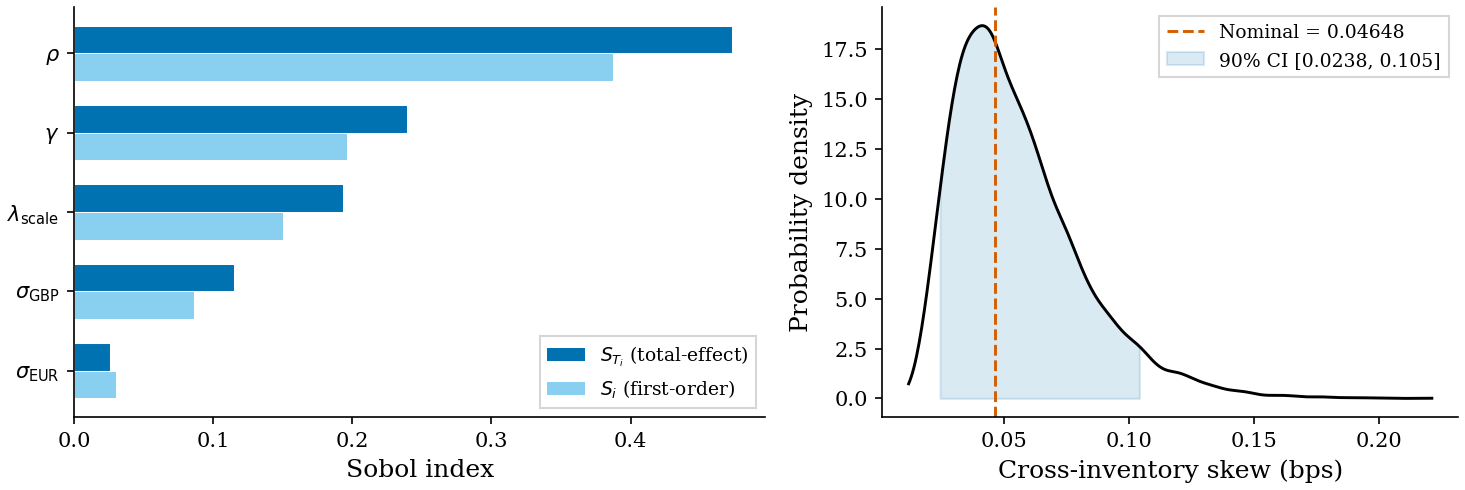

Saved: report/figures/fig_sa_qoi3.pdf


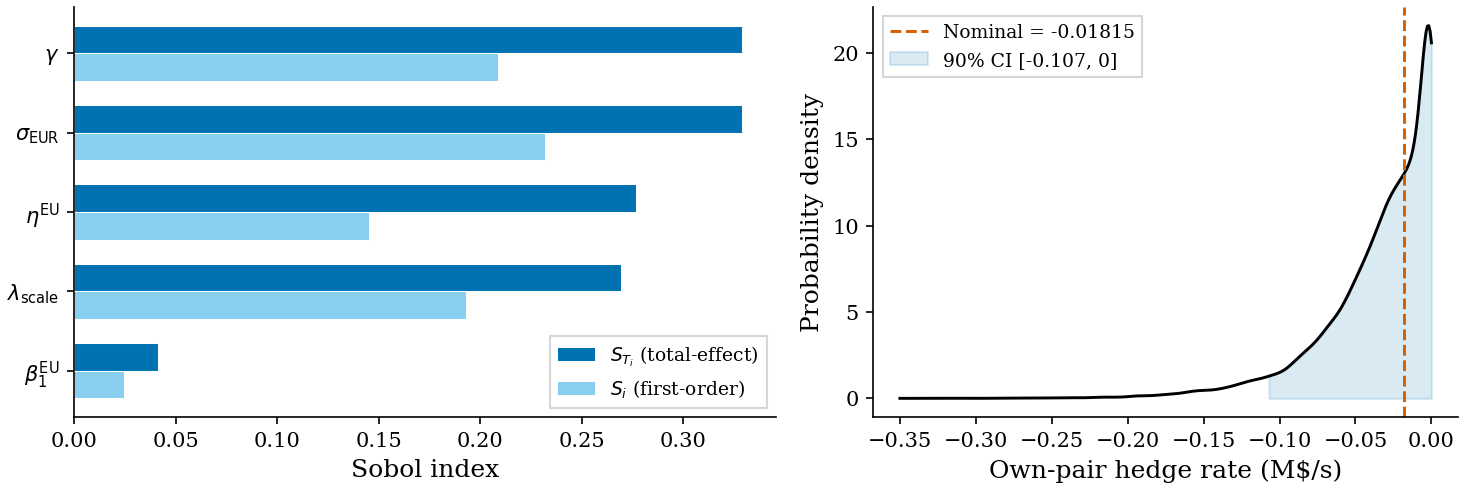

Saved: report/figures/fig_sa_qoi4.pdf


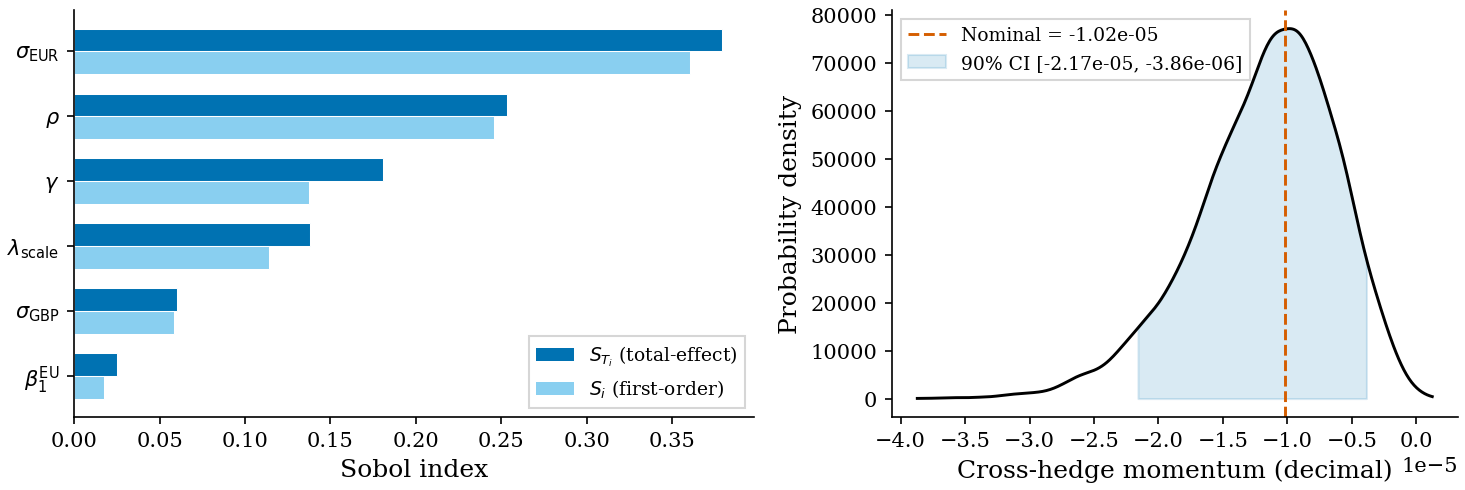

Saved: report/figures/fig_sa_qoi5.pdf


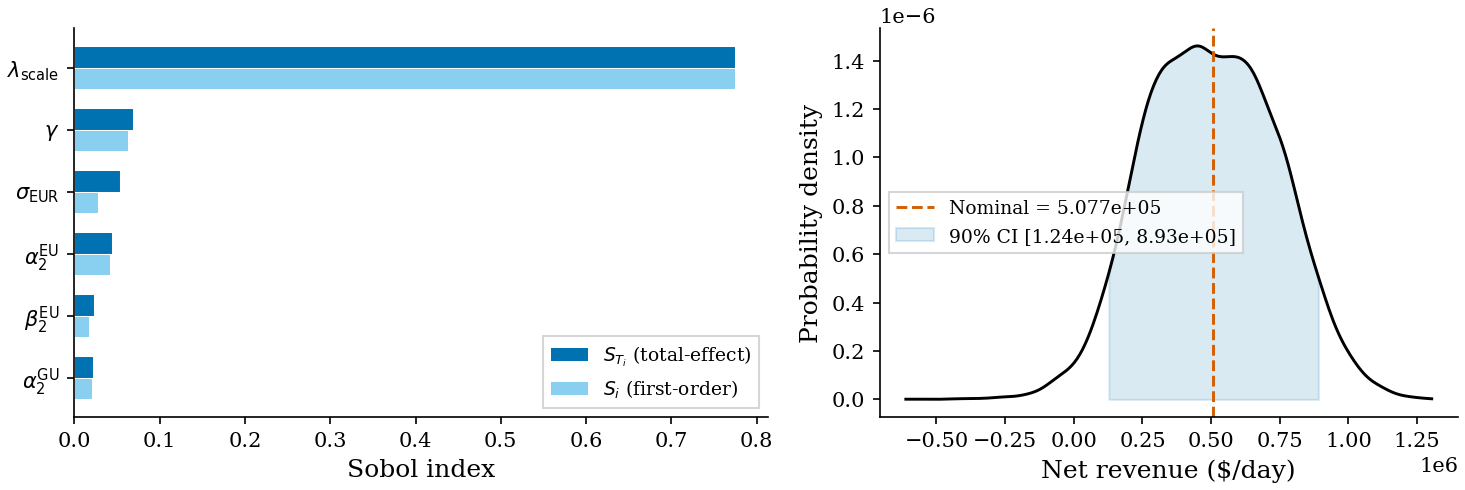

Saved: report/figures/fig_sa_qoi6.pdf


In [17]:
# --- Figures 2-7: Per-QoI combined figures (Sobol bars + KDE) ---

from src.plotting import _RC_PARAMS, COLORS
from src.model import DAY_SECONDS

QOI_FILE_LABELS = [
    "fig_sa_qoi1.pdf", "fig_sa_qoi2.pdf", "fig_sa_qoi3.pdf",
    "fig_sa_qoi4.pdf", "fig_sa_qoi5.pdf", "fig_sa_qoi6.pdf",
]

# Display-time unit overrides: QoI 4 (hedge rate) is stored in M$/day but displayed in M$/s
DISPLAY_SCALE = [1.0, 1.0, 1.0, 1.0 / DAY_SECONDS, 1.0, 1.0]
DISPLAY_LABELS = [
    r"Tier spread differential (bps)",
    r"Own-inventory skew (bps)",
    r"Cross-inventory skew (bps)",
    r"Own-pair hedge rate (M\$/s)",
    r"Cross-hedge momentum (decimal)",
    r"Net revenue (\$/day)",
]

SOBOL_THRESHOLD = 0.02

# Paired colors: dark for S_Ti, light tint for S_i
COLOR_ST = COLORS[0]   # "#0072B2" (Wong blue)
COLOR_SI = '#89CFF0'   # light blue tint

with plt.rc_context(_RC_PARAMS):
    for q in range(N_QOIS):
        fig, (ax_bar, ax_kde) = plt.subplots(
            1, 2, figsize=(10, 3.5), gridspec_kw={'width_ratios': [1.2, 1]})

        # --- Left: Sobol bar chart ---
        mask = S_T[:, q] > SOBOL_THRESHOLD
        idx_filtered = np.where(mask)[0]

        if len(idx_filtered) == 0:
            ax_bar.text(0.5, 0.5, 'No parameters above threshold',
                        ha='center', va='center', transform=ax_bar.transAxes)
            ax_bar.set_xlim(0, 1)
        else:
            sort_order = np.argsort(S_T[idx_filtered, q])[::-1]
            idx_sorted = idx_filtered[sort_order]

            y_pos = np.arange(len(idx_sorted))
            bar_height = 0.35

            for k, i in enumerate(idx_sorted):
                ax_bar.barh(y_pos[k] - bar_height/2, S_T[i, q], height=bar_height,
                           color=COLOR_ST, edgecolor='white', linewidth=0.5)
                ax_bar.barh(y_pos[k] + bar_height/2, S[i, q], height=bar_height,
                           color=COLOR_SI, edgecolor='white', linewidth=0.5)

            ax_bar.set_yticks(y_pos)
            ax_bar.set_yticklabels([PARAM_NAMES[i] for i in idx_sorted])
            ax_bar.invert_yaxis()
            ax_bar.set_xlabel('Sobol index')
            ax_bar.set_xlim(0, None)

            from matplotlib.patches import Patch as LegPatch
            ax_bar.legend(
                handles=[
                    LegPatch(facecolor=COLOR_ST, label=r'$S_{T_i}$ (total-effect)'),
                    LegPatch(facecolor=COLOR_SI, label=r'$S_i$ (first-order)'),
                ],
                loc='lower right', frameon=True, fancybox=False, edgecolor='0.8',
            )

        # --- Right: Forward UQ KDE ---
        scale = DISPLAY_SCALE[q]
        data = fwd_qois[:, q] * scale
        nom_val = nominal_qois[q] * scale

        kde = gaussian_kde(data, bw_method='silverman')
        x_grid = np.linspace(data.min(), data.max(), 400)
        density = kde(x_grid)

        ax_kde.plot(x_grid, density, color='black')
        ax_kde.axvline(nom_val, color=COLORS[1], linestyle='--',
                       label=f'Nominal = {nom_val:.4g}')

        p5, p95 = np.percentile(data, [5, 95])
        ci_mask = (x_grid >= p5) & (x_grid <= p95)
        ax_kde.fill_between(x_grid[ci_mask], density[ci_mask], alpha=0.15,
                            color=COLORS[0],
                            label=f'90% CI [{p5:.3g}, {p95:.3g}]')

        ax_kde.set_xlabel(DISPLAY_LABELS[q])
        ax_kde.set_ylabel('Probability density')
        ax_kde.legend(frameon=True, fancybox=False, edgecolor='0.8')

        fig.tight_layout()
        fpath = os.path.join('report/figures', QOI_FILE_LABELS[q])
        fig.savefig(fpath)
        plt.show()
        print(f"Saved: {fpath}")

## Scatter plots for discussion

Parameter-vs-QoI scatter plots illustrating key nonlinear relationships identified by the sensitivity analysis.

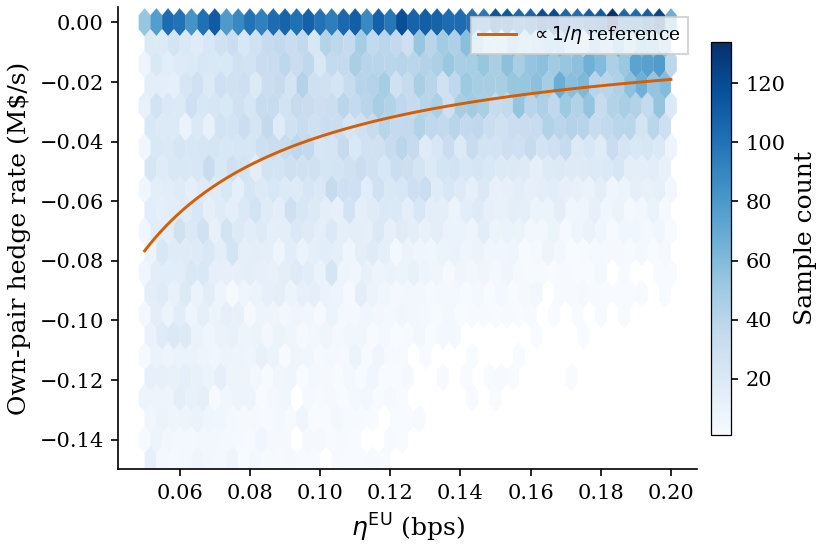

Saved: report/figures/fig_sa_scatter_eta_hedge.pdf


In [18]:
# --- Figure 8: eta_EU vs own-pair hedge rate ---

from src.plotting import _RC_PARAMS, COLORS
from src.model import DAY_SECONDS

eta_idx = 9   # eta EU parameter index
hedge_qoi = 3 # own-pair hedge rate QoI index

eta_vals = all_params[:, eta_idx]
hedge_vals = fwd_qois[:, hedge_qoi] / DAY_SECONDS  # convert M$/day -> M$/s

with plt.rc_context(_RC_PARAMS):
    fig, ax = plt.subplots(figsize=(6, 4))

    # Hexbin for density
    hb = ax.hexbin(eta_vals * 1e4, hedge_vals, gridsize=45, cmap='Blues',
                   mincnt=1, linewidths=0.1, edgecolors='face', rasterized=True)
    cb = fig.colorbar(hb, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label('Sample count')
    cb.outline.set_linewidth(0.6)

    # Reference curve: fit on active points only (outside dead zone)
    active = hedge_vals < -1e-6
    median_product = np.median(hedge_vals[active] * eta_vals[active])
    eta_fine = np.linspace(eta_vals.min(), eta_vals.max(), 200)
    ax.plot(eta_fine * 1e4, median_product / eta_fine, color=COLORS[1],
            linewidth=1.4, label=r'$\propto 1/\eta$ reference')

    ax.set_xlabel(r'$\eta^{\mathrm{EU}}$ (bps)')
    ax.set_ylabel(r'Own-pair hedge rate (M\$/s)')
    ax.set_ylim(-0.15, 0.005)
    ax.legend(frameon=True, fancybox=False, edgecolor='0.8')

    fig.savefig('report/figures/fig_sa_scatter_eta_hedge.pdf')
    plt.show()
    print("Saved: report/figures/fig_sa_scatter_eta_hedge.pdf")

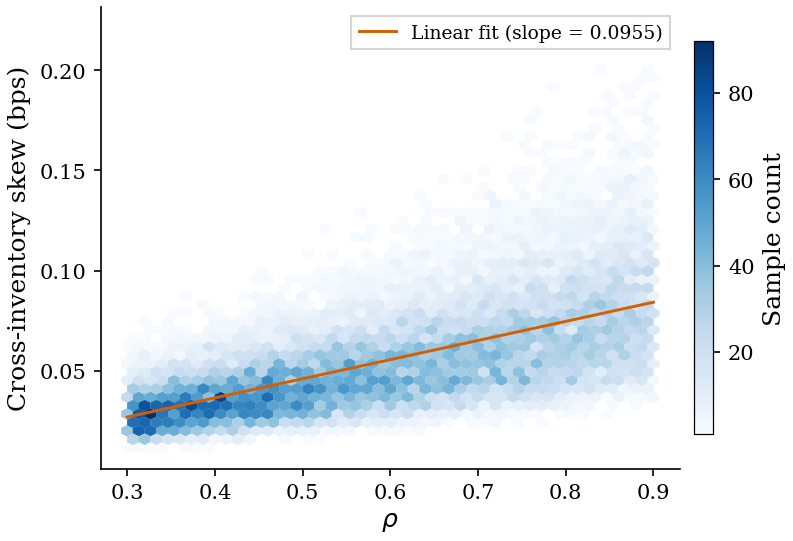

Saved: report/figures/fig_sa_scatter_rho_cross.pdf


In [19]:
# --- Figure 9: rho vs cross-inventory skew ---

rho_idx = 2    # rho parameter index
cross_qoi = 2  # cross-inventory skew QoI index

rho_vals = all_params[:, rho_idx]
cross_vals = fwd_qois[:, cross_qoi]

with plt.rc_context(_RC_PARAMS):
    fig, ax = plt.subplots(figsize=(6, 4))

    hb = ax.hexbin(rho_vals, cross_vals, gridsize=45, cmap='Blues',
                   mincnt=1, linewidths=0.1, edgecolors='face', rasterized=True)
    cb = fig.colorbar(hb, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label('Sample count')
    cb.outline.set_linewidth(0.6)

    # Linear regression fit
    coeffs = np.polyfit(rho_vals, cross_vals, 1)
    rho_fine = np.linspace(rho_vals.min(), rho_vals.max(), 200)
    ax.plot(rho_fine, np.polyval(coeffs, rho_fine), color=COLORS[1],
            linewidth=1.4, label=f'Linear fit (slope = {coeffs[0]:.4f})')

    ax.set_xlabel(r'$\rho$')
    ax.set_ylabel('Cross-inventory skew (bps)')
    ax.legend(frameon=True, fancybox=False, edgecolor='0.8')

    fig.savefig('report/figures/fig_sa_scatter_rho_cross.pdf')
    plt.show()
    print("Saved: report/figures/fig_sa_scatter_rho_cross.pdf")